In [25]:
import numpy as np
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


In [26]:
tickers = ["AAPL", "MSFT"]

data = yf.download(
    tickers,
    start = "2021-01-01",
    end = "2026-09-01",
    auto_adjust = False
)

data.head()

[*********************100%***********************]  2 of 2 completed


Price        Adj Close                   Close                    High  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2021-01-04  125.632500  207.565369  129.410004  217.690002  133.610001   
2021-01-05  127.185776  207.765610  131.009995  217.899994  131.740005   
2021-01-06  122.904510  202.378448  126.599998  212.250000  131.050003   
2021-01-07  127.098419  208.137466  130.919998  218.289993  131.630005   
2021-01-08  128.195389  209.405609  132.050003  219.619995  132.630005   

Price                          Low                    Open              \
Ticker            MSFT        AAPL        MSFT        AAPL        MSFT   
Date                                                                     
2021-01-04  223.000000  126.760002  214.809998  133.520004  222.529999   
2021-01-05  218.520004  128.429993  215.699997  128.889999  217.259995   
2021-01-06  216.490005  126.379997  211.940002  127.720001  212.169998   
2021-01-07  219.339996  127.860001  213.710007  128.360001  214.039993   
2021-01-08  220.580002  130.229996  217.029999  132.429993  218.679993   

Price          Volume            
Ticker           AAPL      MSFT  
Date                             
2021-01-04  143301900  37130100  
2021-01-05   97664900  23823000  
2021-01-06  155088000  35930700  
2021-01-07  109578200  27694500  
2021-01-08  105158200  22956200

## 1. Data Inspection

In [27]:
data.shape

(1421, 12)

In [28]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1421 entries, 2021-01-04 to 2026-08-31
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, AAPL)  1421 non-null   float64
 1   (Adj Close, MSFT)  1421 non-null   float64
 2   (Close, AAPL)      1421 non-null   float64
 3   (Close, MSFT)      1421 non-null   float64
 4   (High, AAPL)       1421 non-null   float64
 5   (High, MSFT)       1421 non-null   float64
 6   (Low, AAPL)        1421 non-null   float64
 7   (Low, MSFT)        1421 non-null   float64
 8   (Open, AAPL)       1421 non-null   float64
 9   (Open, MSFT)       1421 non-null   float64
 10  (Volume, AAPL)     1421 non-null   int64  
 11  (Volume, MSFT)     1421 non-null   int64  
dtypes: float64(10), int64(2)
memory usage: 144.3 KB


In [29]:
data.isna().sum()

Price      Ticker
Adj Close  AAPL      0
           MSFT      0
Close      AAPL      0
           MSFT      0
High       AAPL      0
           MSFT      0
Low        AAPL      0
           MSFT      0
Open       AAPL      0
           MSFT      0
Volume     AAPL      0
           MSFT      0
dtype: int64

In [30]:
data.head()

Price        Adj Close                   Close                    High  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2021-01-04  125.632500  207.565369  129.410004  217.690002  133.610001   
2021-01-05  127.185776  207.765610  131.009995  217.899994  131.740005   
2021-01-06  122.904510  202.378448  126.599998  212.250000  131.050003   
2021-01-07  127.098419  208.137466  130.919998  218.289993  131.630005   
2021-01-08  128.195389  209.405609  132.050003  219.619995  132.630005   

Price                          Low                    Open              \
Ticker            MSFT        AAPL        MSFT        AAPL        MSFT   
Date                                                                     
2021-01-04  223.000000  126.760002  214.809998  133.520004  222.529999   
2021-01-05  218.520004  128.429993  215.699997  128.889999  217.259995   
2021-01-06  216.490005  126.379997  211.940002  127.720001  212.169998   
2021-01-07  219.339996  127.860001  213.710007  128.360001  214.039993   
2021-01-08  220.580002  130.229996  217.029999  132.429993  218.679993   

Price          Volume            
Ticker           AAPL      MSFT  
Date                             
2021-01-04  143301900  37130100  
2021-01-05   97664900  23823000  
2021-01-06  155088000  35930700  
2021-01-07  109578200  27694500  
2021-01-08  105158200  22956200

In [31]:
data.tail()

Price        Adj Close                   Close                    High  \
Ticker            AAPL        MSFT        AAPL        MSFT        AAPL   
Date                                                                     
2026-08-25  309.899994  491.709991  309.899994  491.709991  313.589996   
2026-08-26  313.450012  496.369995  313.450012  496.369995  315.429993   
2026-08-27  314.579987  505.059998  314.579987  505.059998  315.399994   
2026-08-28  319.700012  513.530029  319.700012  513.530029  322.369995   
2026-08-31  316.850006  507.290009  316.850006  507.290009  321.239990   

Price                          Low                    Open              \
Ticker            MSFT        AAPL        MSFT        AAPL        MSFT   
Date                                                                     
2026-08-25  492.440002  308.209991  484.299988  310.790009  485.440002   
2026-08-26  497.399994  308.799988  487.309998  310.299988  487.850006   
2026-08-27  506.480011  309.399994  490.079987  310.549988  494.880005   
2026-08-28  517.780029  315.450012  504.869995  316.850006  505.329987   
2026-08-31  512.190002  312.799988  506.390015  319.600006  510.380005   

Price         Volume            
Ticker          AAPL      MSFT  
Date                            
2026-08-25  25869800  19519000  
2026-08-26  34024500  20758900  
2026-08-27  32419200  28688800  
2026-08-28  38649400  29207300  
2026-08-31  41242700  27208900

In [32]:
data.index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2026-08-18', '2026-08-19', '2026-08-20', '2026-08-21',
               '2026-08-24', '2026-08-25', '2026-08-26', '2026-08-27',
               '2026-08-28', '2026-08-31'],
              dtype='datetime64[s]', name='Date', length=1421, freq=None)

In [33]:
data.index.min()

Timestamp('2021-01-04 00:00:00')

In [34]:
data.index.max()

Timestamp('2026-08-31 00:00:00')

## 2. Closing Price Analysis

In [35]:
close = data["Close"]

close.head()

Ticker,AAPL,MSFT
Date,,
2021-01-04,129.410004,217.690002
2021-01-05,131.009995,217.899994
2021-01-06,126.599998,212.250000
2021-01-07,130.919998,218.289993
2021-01-08,132.050003,219.619995


In [36]:
close.shape

(1421, 2)

In [37]:
close.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1421 entries, 2021-01-04 to 2026-08-31
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1421 non-null   float64
 1   MSFT    1421 non-null   float64
dtypes: float64(2)
memory usage: 33.3 KB


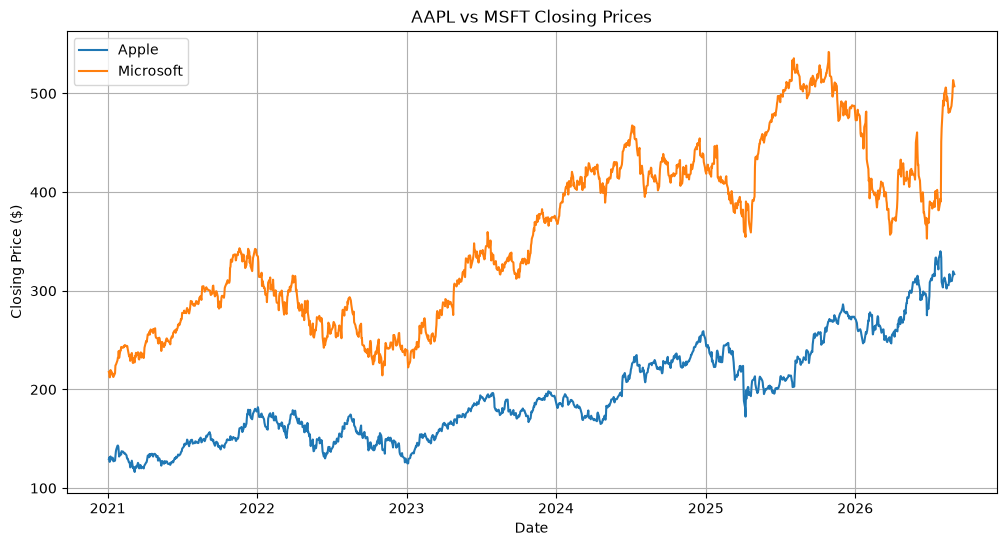

In [38]:
plt.figure(figsize=(12, 6))

plt.plot(close.index, close["AAPL"], label="Apple")
plt.plot(close.index, close["MSFT"], label="Microsoft")

plt.title("AAPL vs MSFT Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
normalized = close / close.iloc[0] * 100

In [40]:
normalized.head()

Ticker,AAPL,MSFT
Date,,
2021-01-04,100.000000,100.000000
2021-01-05,101.236373,100.096464
2021-01-06,97.828603,97.501032
2021-01-07,101.166830,100.275617
2021-01-08,102.040027,100.886578


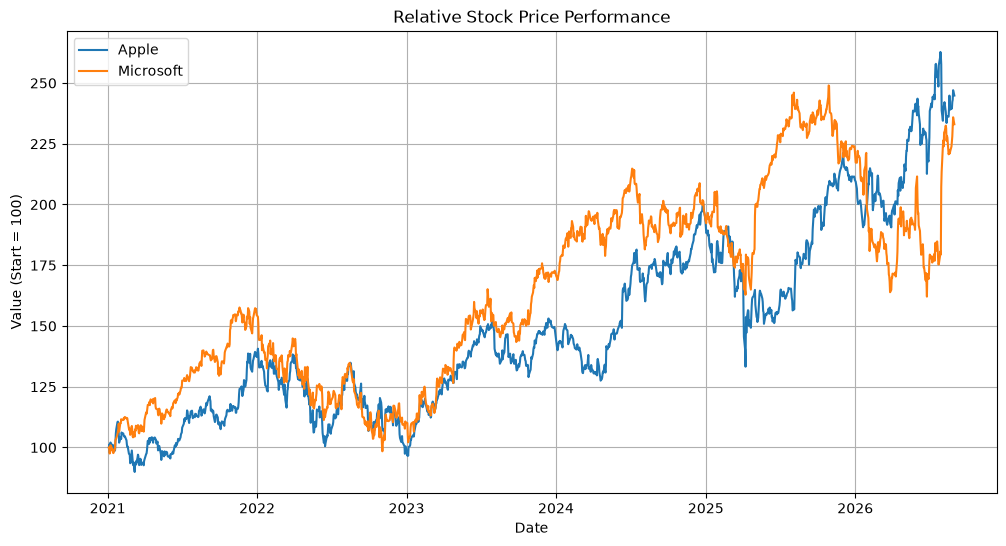

In [41]:
plt.figure(figsize=(12, 6))

plt.plot(normalized.index, normalized["AAPL"], label="Apple")
plt.plot(normalized.index, normalized["MSFT"], label="Microsoft")

plt.title("Relative Stock Price Performance")
plt.xlabel("Date")
plt.ylabel("Value (Start = 100)")
plt.legend()
plt.grid(True)

plt.show()

## 3. Weekly and Monthly Resampling

In [43]:
weekly_close = close.resample("W").last()
weekly_close.head()

Ticker,AAPL,MSFT
Date,,
2021-01-10,132.050003,219.619995
2021-01-17,127.139999,212.649994
2021-01-24,139.070007,225.949997
2021-01-31,131.960007,231.960007
2021-02-07,136.759995,242.199997


In [44]:
weekly_close.shape

(296, 2)

In [45]:
print("Daily observations:", len(close))
print("Weekly observations:", len(weekly_close))

Daily observations: 1421
Weekly observations: 296


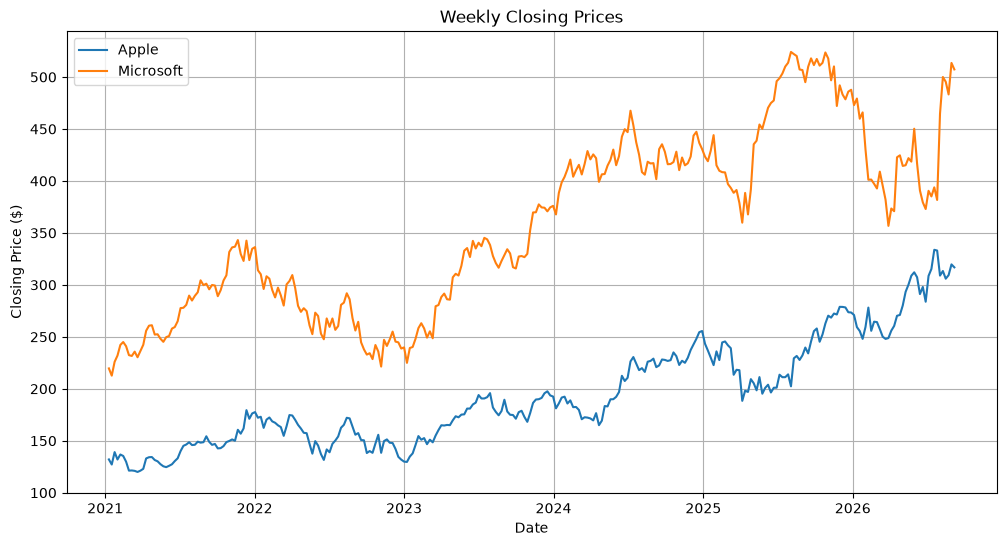

In [46]:
plt.figure(figsize=(12, 6))

plt.plot(
    weekly_close.index,
    weekly_close["AAPL"],
    label="Apple"
)

plt.plot(
    weekly_close.index,
    weekly_close["MSFT"],
    label="Microsoft"
)

plt.title("Weekly Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)

plt.show()

In [47]:
monthly_close = close.resample("ME").last()
monthly_close.head()

Ticker,AAPL,MSFT
Date,,
2021-01-31,131.960007,231.960007
2021-02-28,121.260002,232.380005
2021-03-31,122.150002,235.770004
2021-04-30,131.460007,252.179993
2021-05-31,124.610001,249.679993


In [48]:
monthly_close.shape

(68, 2)

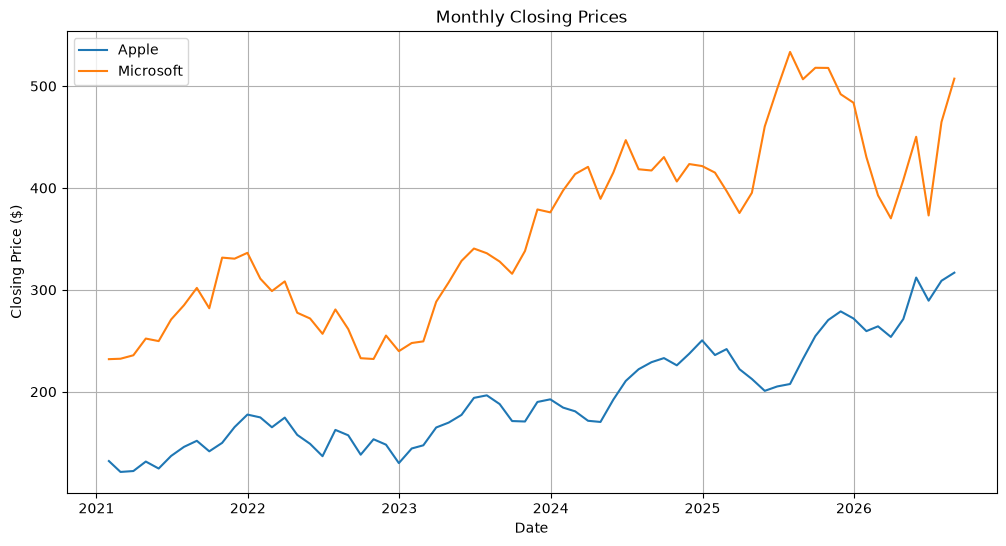

In [49]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_close.index,
    monthly_close["AAPL"],
    label="Apple"
)

plt.plot(
    monthly_close.index,
    monthly_close["MSFT"],
    label="Microsoft"
)

plt.title("Monthly Closing Prices")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True)

plt.show()

## 4. Moving Average

In [50]:
aapl = close[["AAPL"]].copy()

aapl["MA_20"] = aapl["AAPL"].rolling(20).mean()
aapl["MA_200"] = aapl["AAPL"].rolling(200).mean()

aapl.head()

Ticker,AAPL,MA_20,MA_200
Date,,,
2021-01-04,129.410004,NaN,NaN
2021-01-05,131.009995,NaN,NaN
2021-01-06,126.599998,NaN,NaN
2021-01-07,130.919998,NaN,NaN
2021-01-08,132.050003,NaN,NaN


In [51]:
aapl.dropna().head()

Ticker,AAPL,MA_20,MA_200
Date,,,
2021-10-18,146.550003,143.305499,135.63210
2021-10-19,148.759995,143.571999,135.72885
2021-10-20,149.259995,143.742498,135.82010
2021-10-21,149.479996,143.874998,135.93450
2021-10-22,148.690002,143.963498,136.02335


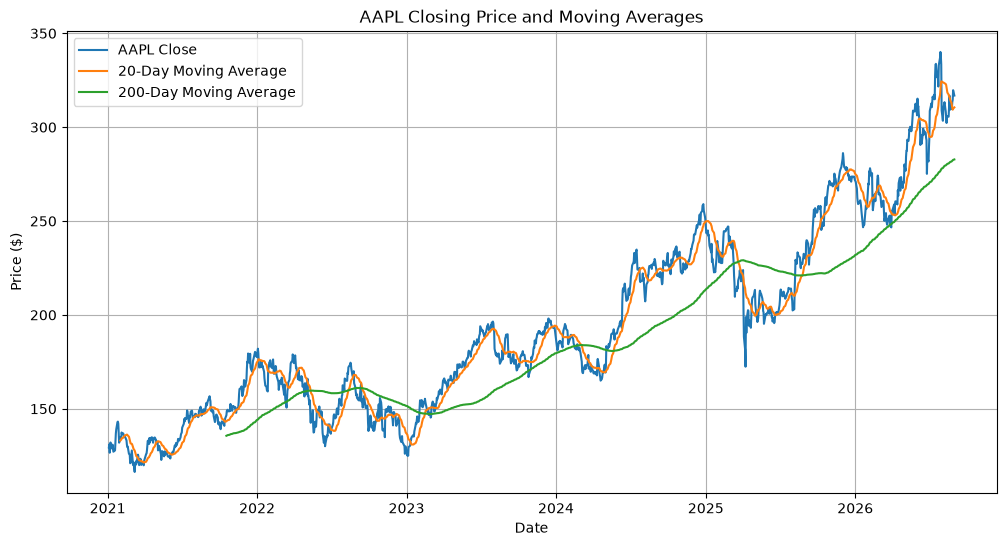

In [52]:
plt.figure(figsize=(12, 6))

plt.plot(
    aapl.index,
    aapl["AAPL"],
    label="AAPL Close"
)

plt.plot(
    aapl.index,
    aapl["MA_20"],
    label="20-Day Moving Average"
)

plt.plot(
    aapl.index,
    aapl["MA_200"],
    label="200-Day Moving Average"
)

plt.title("AAPL Closing Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)

plt.show()

In [53]:
msft = close[["MSFT"]].copy()

msft["MA_20"] = msft["MSFT"].rolling(20).mean()
msft["MA_200"] = msft["MSFT"].rolling(200).mean()

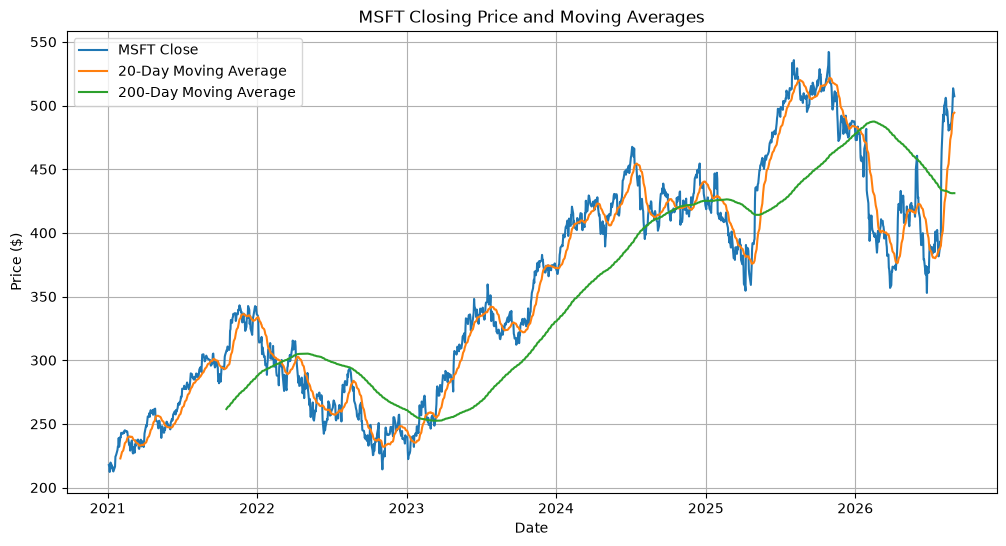

In [54]:
plt.figure(figsize=(12, 6))

plt.plot(
    msft.index,
    msft["MSFT"],
    label="MSFT Close"
)

plt.plot(
    msft.index,
    msft["MA_20"],
    label="20-Day Moving Average"
)

plt.plot(
    msft.index,
    msft["MA_200"],
    label="200-Day Moving Average"
)

plt.title("MSFT Closing Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)

plt.show()

## 5. Trading Volume

In [56]:
volume = data["Volume"]

volume.head()

Ticker,AAPL,MSFT
Date,,
2021-01-04,143301900,37130100
2021-01-05,97664900,23823000
2021-01-06,155088000,35930700
2021-01-07,109578200,27694500
2021-01-08,105158200,22956200


In [57]:
volume.mean()

Ticker
AAPL    6.751491e+07
MSFT    2.682762e+07
dtype: float64

In [60]:
volume.describe()   

Ticker,AAPL,MSFT
count,1.421000e+03,1.421000e+03
mean,6.751491e+07,2.682762e+07
std,2.991075e+07,1.195180e+07
min,1.791060e+07,5.855900e+06
25%,4.648250e+07,1.948500e+07
50%,6.010760e+07,2.412670e+07
75%,8.107720e+07,3.081660e+07
max,3.186799e+08,1.862016e+08


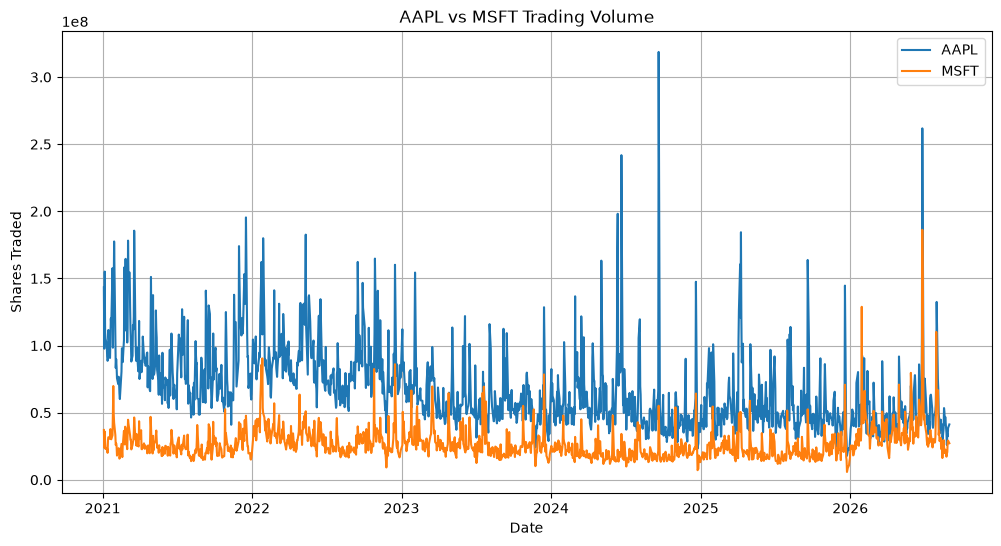

In [62]:
plt.figure(figsize=(12, 6))

plt.plot(
    volume.index,
    volume["AAPL"],
    label="AAPL"
)

plt.plot(
    volume.index,
    volume["MSFT"],
    label="MSFT"
)

plt.title("AAPL vs MSFT Trading Volume")
plt.xlabel("Date")
plt.ylabel("Shares Traded")
plt.legend()
plt.grid(True)

plt.show()

In [63]:
monthly_volume = volume.resample("ME").sum()

In [64]:
monthly_volume.head()

Ticker,AAPL,MSFT
Date,,
2021-01-31,2240262000,648076400
2021-02-28,1833855600,490962200
2021-03-31,2650418200,724945800
2021-04-30,1889857500,568661600
2021-05-31,1711934900,495084900


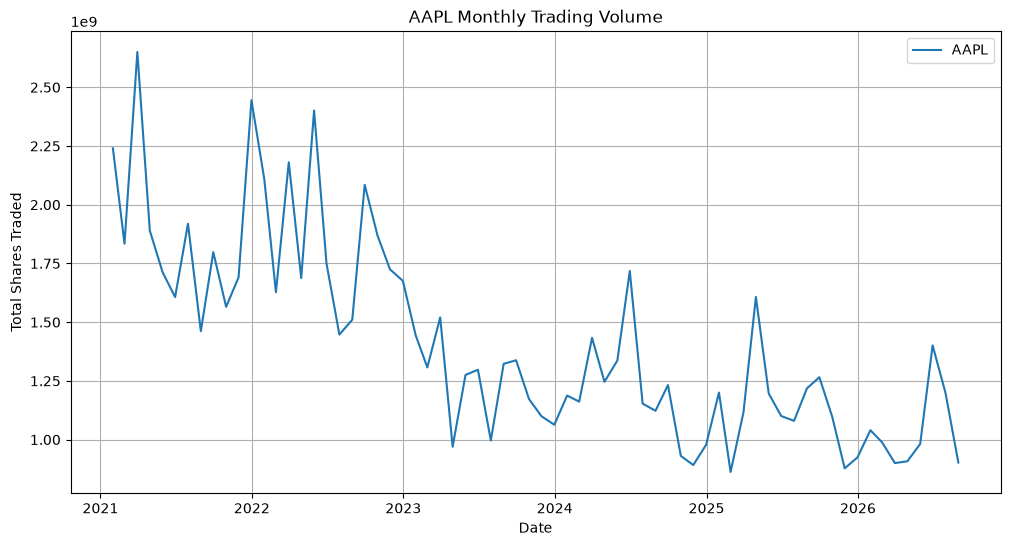

In [65]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_volume.index,
    monthly_volume["AAPL"],
    label="AAPL"
)

plt.title("AAPL Monthly Trading Volume")
plt.xlabel("Date")
plt.ylabel("Total Shares Traded")
plt.legend()
plt.grid(True)

plt.show()